# Odor Label Consistency Analysis  : GoodScents vs Leffingwell


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.stats import spearmanr
from collections import Counter
%matplotlib inline

pd.set_option('display.width', 120)


FILES = {
    'goodscents':  f'goodscents_processed.csv',
    'leffingwell': f'leffingwell_processed.csv',
}
DATASET_NAMES = list(FILES.keys())
print(f"{len(DATASET_NAMES)} datasets registered.")

2 datasets registered.


## Step 1 : Build the 138-label vocabulary and load all 8 datasets



In [5]:
TARGET_138 = ['alcoholic', 'aldehydic', 'alliaceous', 'almond', 'amber', 'animal', 'anisic', 'apple',
'apricot', 'aromatic', 'balsamic', 'banana', 'beefy', 'bergamot', 'berry', 'bitter', 'black currant',
'brandy', 'burnt', 'buttery', 'cabbage', 'camphoreous', 'caramellic', 'cedar', 'celery', 'chamomile',
'cheesy', 'cherry', 'chocolate', 'cinnamon', 'citrus', 'clean', 'clove', 'cocoa', 'coconut', 'coffee',
'cognac', 'cooked', 'cooling', 'cortex', 'coumarinic', 'creamy', 'cucumber', 'dairy', 'dry', 'earthy',
'ethereal', 'fatty', 'fermented', 'fishy', 'floral', 'fresh', 'fruit skin', 'fruity', 'garlic', 'gassy',
'geranium', 'grape', 'grapefruit', 'grassy', 'green', 'hawthorn', 'hay', 'hazelnut', 'herbal', 'honey',
'hyacinth', 'jasmin', 'juicy', 'ketonic', 'lactonic', 'lavender', 'leafy', 'leathery', 'lemon', 'lily',
'malty', 'meaty', 'medicinal', 'melon', 'metallic', 'milky', 'mint', 'muguet', 'mushroom', 'musk',
'musty', 'natural', 'nutty', 'odorless', 'oily', 'onion', 'orange', 'orangeflower', 'orris', 'ozone',
'peach', 'pear', 'phenolic', 'pine', 'pineapple', 'plum', 'popcorn', 'potato', 'powdery', 'pungent',
'radish', 'raspberry', 'ripe', 'roasted', 'rose', 'rummy', 'sandalwood', 'savory', 'sharp', 'smoky',
'soapy', 'solvent', 'sour', 'spicy', 'strawberry', 'sulfurous', 'sweaty', 'sweet', 'tea', 'terpenic',
'tobacco', 'tomato', 'tropical', 'vanilla', 'vegetable', 'vetiver', 'violet', 'warm', 'waxy', 'weedy',
'winey', 'woody']
print(f"Target labels: {len(TARGET_138)}")

RENAME_MAP = {'black currant': 'currant black currant', 'mint': 'minty'}
FRUIT_SKIN_SOURCES = ['apple skin', 'cucumber skin', 'grape skin', 'pear skin', 'plum skin']
SIMPLE_LABELS = [l for l in TARGET_138 if l not in ('fruit skin',)]

def load_dataset(name, path):
    needed_cols = ['SMILES'] + [RENAME_MAP.get(l, l) for l in SIMPLE_LABELS if l != 'fruit skin'] + FRUIT_SKIN_SOURCES
    needed_cols = list(dict.fromkeys(needed_cols))  # dedupe, preserve order
    df = pd.read_csv(path, usecols=needed_cols)
    df = df.rename(columns={v: k for k, v in RENAME_MAP.items()})
    df['fruit skin'] = (df[FRUIT_SKIN_SOURCES].sum(axis=1) > 0).astype(int)
    df = df.drop(columns=FRUIT_SKIN_SOURCES)
    df = df.drop_duplicates(subset='SMILES', keep='first').set_index('SMILES')
    return df[TARGET_138]

DFS = {}
for name, path in FILES.items():
    DFS[name] = load_dataset(name, path)
    print(f"{name}: {DFS[name].shape[0]} molecules")

assert all(DFS[n].shape[1] == 138 for n in DATASET_NAMES), "label count mismatch!"
print("\nAll datasets loaded with 138 usable labels each.")

Target labels: 138
goodscents: 4342 molecules
leffingwell: 3523 molecules

All datasets loaded with 138 usable labels each.


## Step 2 : Identifying  shared molecules


In [6]:
smiles_sets = {name: set(DFS[name].index) for name in DATASET_NAMES}
smiles_membership = Counter()
for name, s in smiles_sets.items():
    for smi in s:
        smiles_membership[smi] += 1

shared_smiles = [smi for smi, k in smiles_membership.items() if k >= 2]
print(f"Molecules in >=2 datasets: {len(shared_smiles)}")

# which datasets contain each shared molecule
smiles_to_datasets = {smi: [n for n in DATASET_NAMES if smi in smiles_sets[n]] for smi in shared_smiles}

Molecules in >=2 datasets: 726


## Metric 1 : Molecule-level Consistency Score(the average pair jaccard similarity jaccard consistency)

For molecule $m$ present in datasets $i \in D_m$ ,  $S_i$ be its
set of positive labels (out of the 138) in dataset $i$.

For every pair $(i,j)$ with $i,j \in D_m$, $i<j$:

$$J_{i,j} = \frac{|S_i \cap S_j|}{|S_i \cup S_j|}$$



$$\text{Score}_m = \frac{1}{|P_m|}\sum_{(i,j) \in P_m} J_{i,j}$$

where $P_m$ is the set of valid (non 0/0) pairs among the $\binom{k}{2}$ dataset pairs
containing $m$.

In [7]:
def label_set(name, smi):
    row = DFS[name].loc[smi]
    return set(row.index[row.values == 1])

scores = []
for smi in shared_smiles:
    ds = smiles_to_datasets[smi]
    pair_jaccards = []
    for i, j in combinations(ds, 2):
        Si, Sj = label_set(i, smi), label_set(j, smi)
        if not Si and not Sj:
            continue  # exclude 0/0 pairs
        union = Si | Sj
        pair_jaccards.append(len(Si & Sj) / len(union))
    if pair_jaccards:
        scores.append({'SMILES': smi, 'k': len(ds), 'n_valid_pairs': len(pair_jaccards),
                        'Score_m': np.mean(pair_jaccards)})

score_df = pd.DataFrame(scores)
print(f"Molecules with a defined Score_m: {len(score_df)} / {len(shared_smiles)}")
score_df.describe()

Molecules with a defined Score_m: 724 / 726


,k,n_valid_pairs,Score_m
count,724.0,724.0,724.000000
mean,2.0,1.0,0.313708
std,0.0,0.0,0.237515
min,2.0,1.0,0.000000
25%,2.0,1.0,0.166667
50%,2.0,1.0,0.272727
75%,2.0,1.0,0.444444
max,2.0,1.0,1.000000


### Plot 1 : Distribution of Score_m

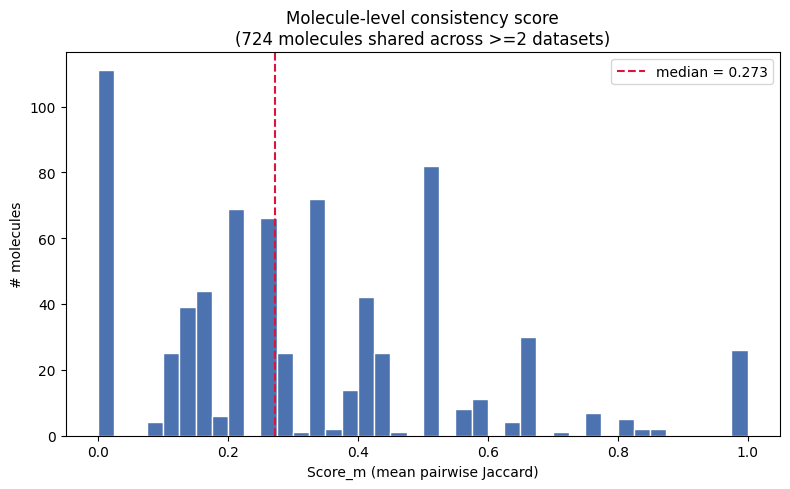

In [8]:
fig, ax = plt.subplots(figsize=(8,5))
ax.hist(score_df['Score_m'], bins=40, color='#4C72B0', edgecolor='white')
ax.axvline(score_df['Score_m'].median(), color='crimson', linestyle='--',
           label=f"median = {score_df['Score_m'].median():.3f}")
ax.set_xlabel('Score_m (mean pairwise Jaccard)')
ax.set_ylabel('# molecules')
ax.set_title(f'Molecule-level consistency score\n({len(score_df)} molecules shared across >=2 datasets)')
ax.legend()
plt.tight_layout()
plt.show()

## Metric 2 : Positive  Agreement (PA) per label

For label $L$ and dataset pair $(i,j)$, restricted to molecules present in **both**:

- $a$ = molecules where in both datasets are 1

- $b$ = molecules where in $i$  are 1

- $c$ = molecules where in $j$  are 1

$$PA_{i,j}(L) = \frac{2a}{2a + b + c}$$



$$PA(L) = \frac{1}{|\text{valid pairs}|}\sum_{(i,j)} PA_{i,j}(L)$$

In [10]:
pairs = list(combinations(DATASET_NAMES, 2))

def abc_for_pair(name_i, name_j, label):
    common = smiles_sets[name_i] & smiles_sets[name_j]
    if not common:
        return 0, 0, 0
    common = list(common)
    vi = DFS[name_i].loc[common, label].values
    vj = DFS[name_j].loc[common, label].values
    a = int(((vi==1) & (vj==1)).sum())
    b = int(((vi==1) & (vj==0)).sum())
    c = int(((vi==0) & (vj==1)).sum())
    return a, b, c

pa_results = []
for label in TARGET_138:
    pa_vals = []
    for ni, nj in pairs:
        a, b, c = abc_for_pair(ni, nj, label)
        denom = 2*a + b + c
        if denom > 0:
            pa_vals.append(2*a/denom)
    pa_results.append({'label': label, 'PA': np.mean(pa_vals) if pa_vals else np.nan,
                        'n_valid_pairs': len(pa_vals)})

pa_df = pd.DataFrame(pa_results).sort_values('PA')
pa_df.to_csv('pa_per_label_gs_lw.csv', index=False)
pa_df

,label,PA,n_valid_pairs
3,almond,0.0,1
4,amber,0.0,1
6,anisic,0.0,1
9,aromatic,0.0,1
16,black currant,0.0,1
...,...,...,...
32,clove,NaN,0
61,hawthorn,NaN,0
112,sandalwood,NaN,0
115,smoky,NaN,0


### Plot 3 : PA_L sorted (bottom 20  and top 20)

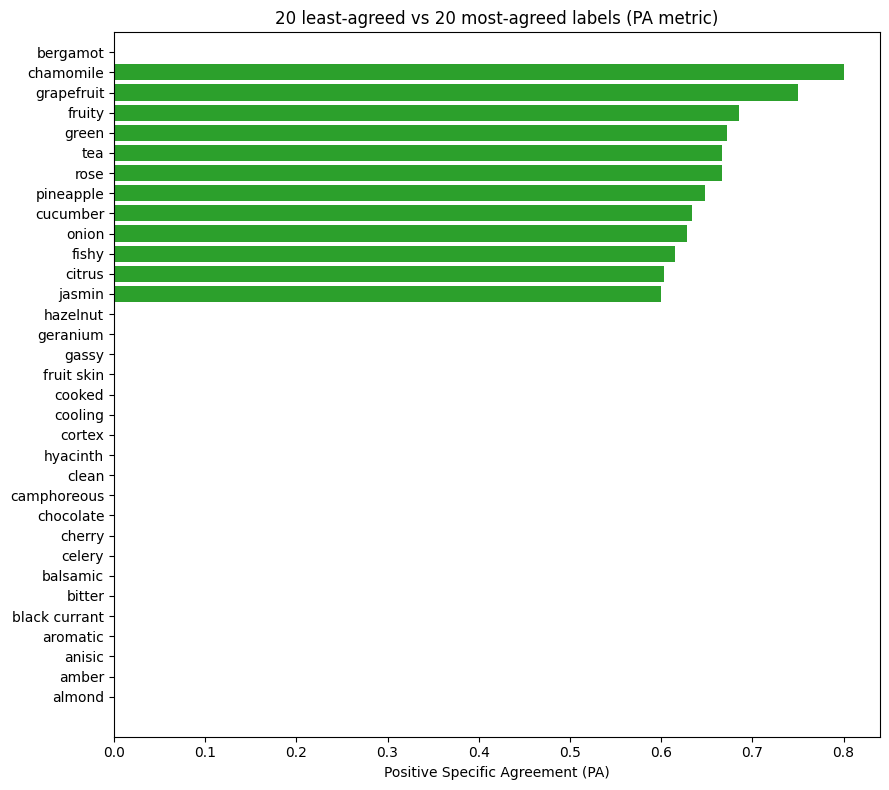

In [11]:
combo = pd.concat([pa_df.head(20), pa_df.tail(20)])
fig, ax = plt.subplots(figsize=(9,8))
colors = ['#d62728' if v < 0.3 else '#2ca02c' for v in combo['PA']]
ax.barh(combo['label'], combo['PA'], color=colors)
ax.set_xlabel('Positive Specific Agreement (PA)')
ax.set_title('20 least-agreed vs 20 most-agreed labels (PA metric)')
plt.tight_layout()
plt.show()

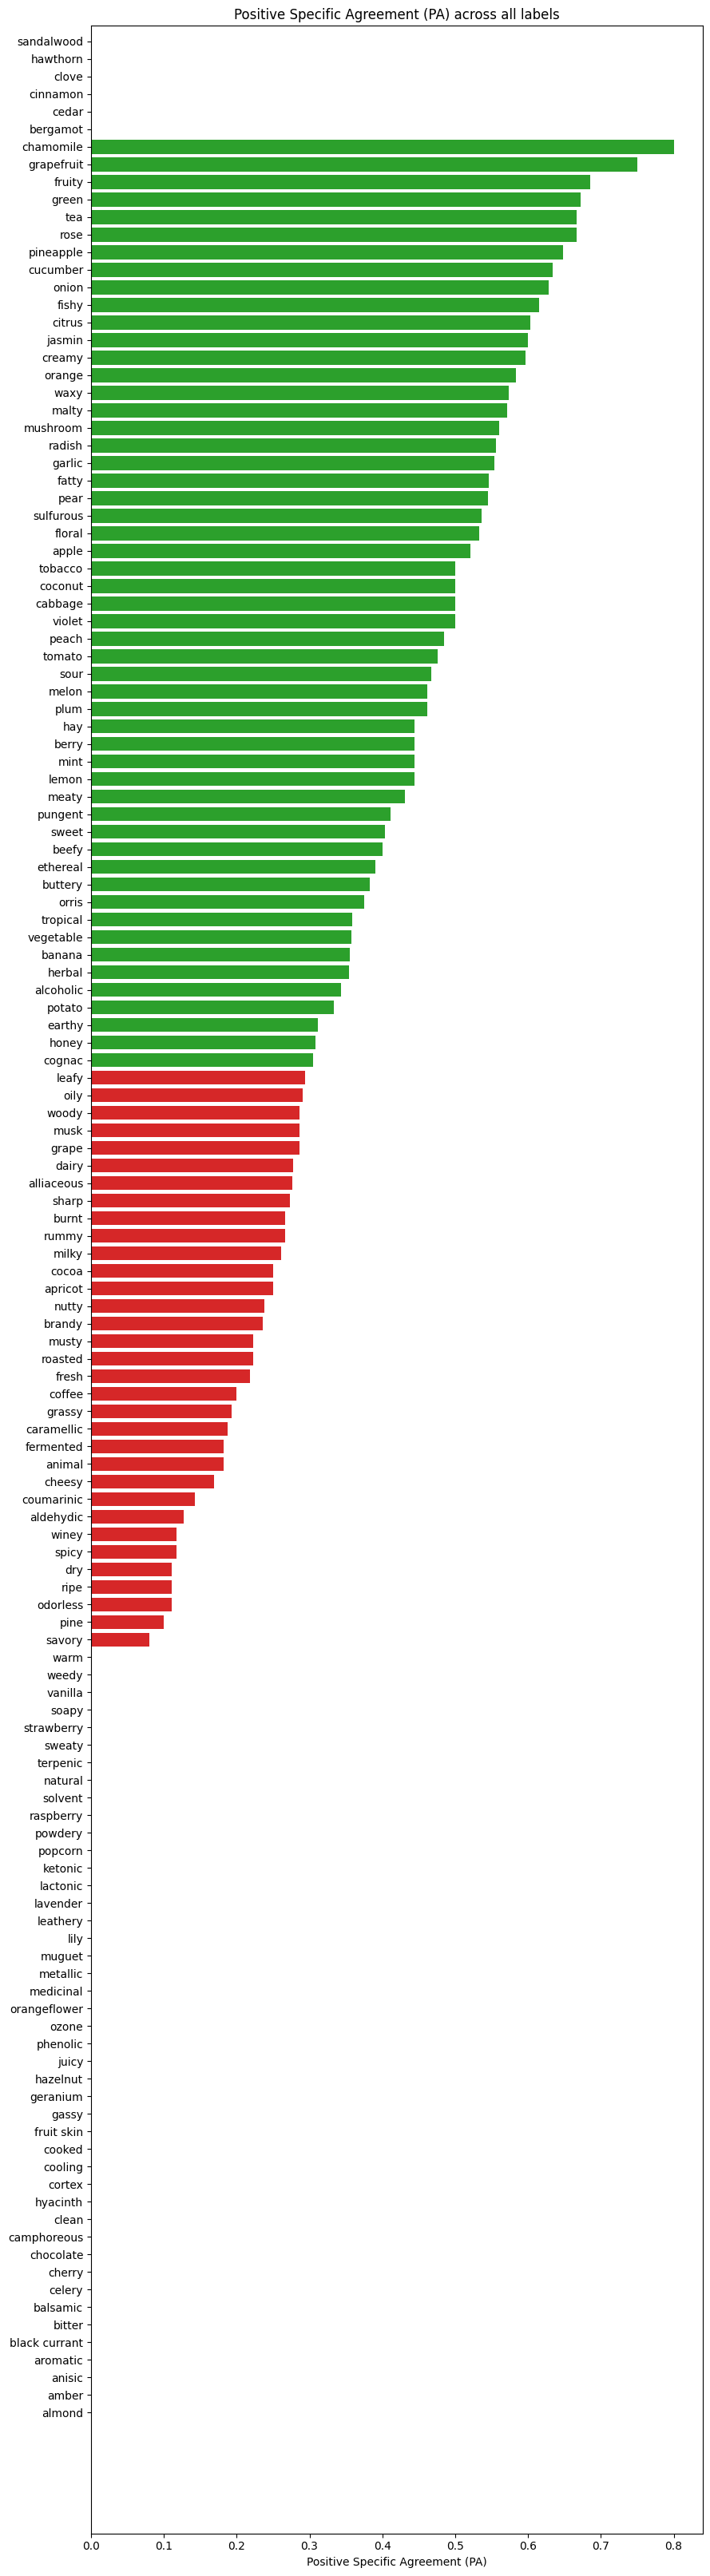

In [12]:
pa_sorted = pa_df.sort_values('PA', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 0.22 * len(pa_sorted) + 2))
colors = ['#d62728' if v < 0.3 else '#2ca02c' for v in pa_sorted['PA']]
ax.barh(pa_sorted['label'], pa_sorted['PA'], color=colors)
ax.set_xlabel('Positive Specific Agreement (PA)')
ax.set_title('Positive Specific Agreement (PA) across all labels')
plt.tight_layout()
plt.show()